In [1]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['pdf.fonttype'] = 42

In [57]:
te_df = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\03-Machine Learning\result\64\metrics_64.csv")

In [58]:
te_df.head()

,all_loss,all_auc,all_acc,all_mcc,all_f1,all_pre,all_se,all_sp,all_Youden_Index,all_Best_Threshold
0,0.657536,0.822350,0.751567,0.501803,0.735171,0.750853,0.720131,0.780451,0.410784,0.517837
1,0.570565,0.811789,0.730408,0.465867,0.683241,0.781053,0.607201,0.843609,0.426467,0.477312
2,0.572630,0.811019,0.744514,0.487921,0.721843,0.754011,0.692308,0.792481,0.499075,0.486426


In [59]:
auc = te_df['all_auc'].tolist()
acc = te_df['all_acc'].tolist()
mcc = te_df['all_mcc'].tolist()
f1 = te_df['all_f1'].tolist()
pre = te_df['all_pre'].tolist()
se = te_df['all_se'].tolist()
sp = te_df['all_sp'].tolist()
yi = te_df['all_Youden_Index'].tolist()
bt = te_df['all_Best_Threshold'].tolist()

In [60]:
scores = {
    'AUC':auc,
    'Accuracy':acc,
    'MCC':mcc,
    'F1':f1,
    'Precision':pre,
    'Sensitivity':se,
    'Specificity':sp,
    'Youden_Index':yi
}
scores

{'AUC': [0.822349655, 0.811788883, 0.811018545],
 'Accuracy': [0.751567398, 0.730407524, 0.744514107],
 'MCC': [0.501803119, 0.465867298, 0.487921145],
 'F1': [0.735171261, 0.683241252, 0.721843003],
 'Precision': [0.750853242, 0.781052632, 0.754010695],
 'Sensitivity': [0.720130933, 0.607201309, 0.692307692],
 'Specificity': [0.780451128, 0.843609023, 0.792481203],
 'Youden_Index': [0.410784185, 0.426466763, 0.499075443]}

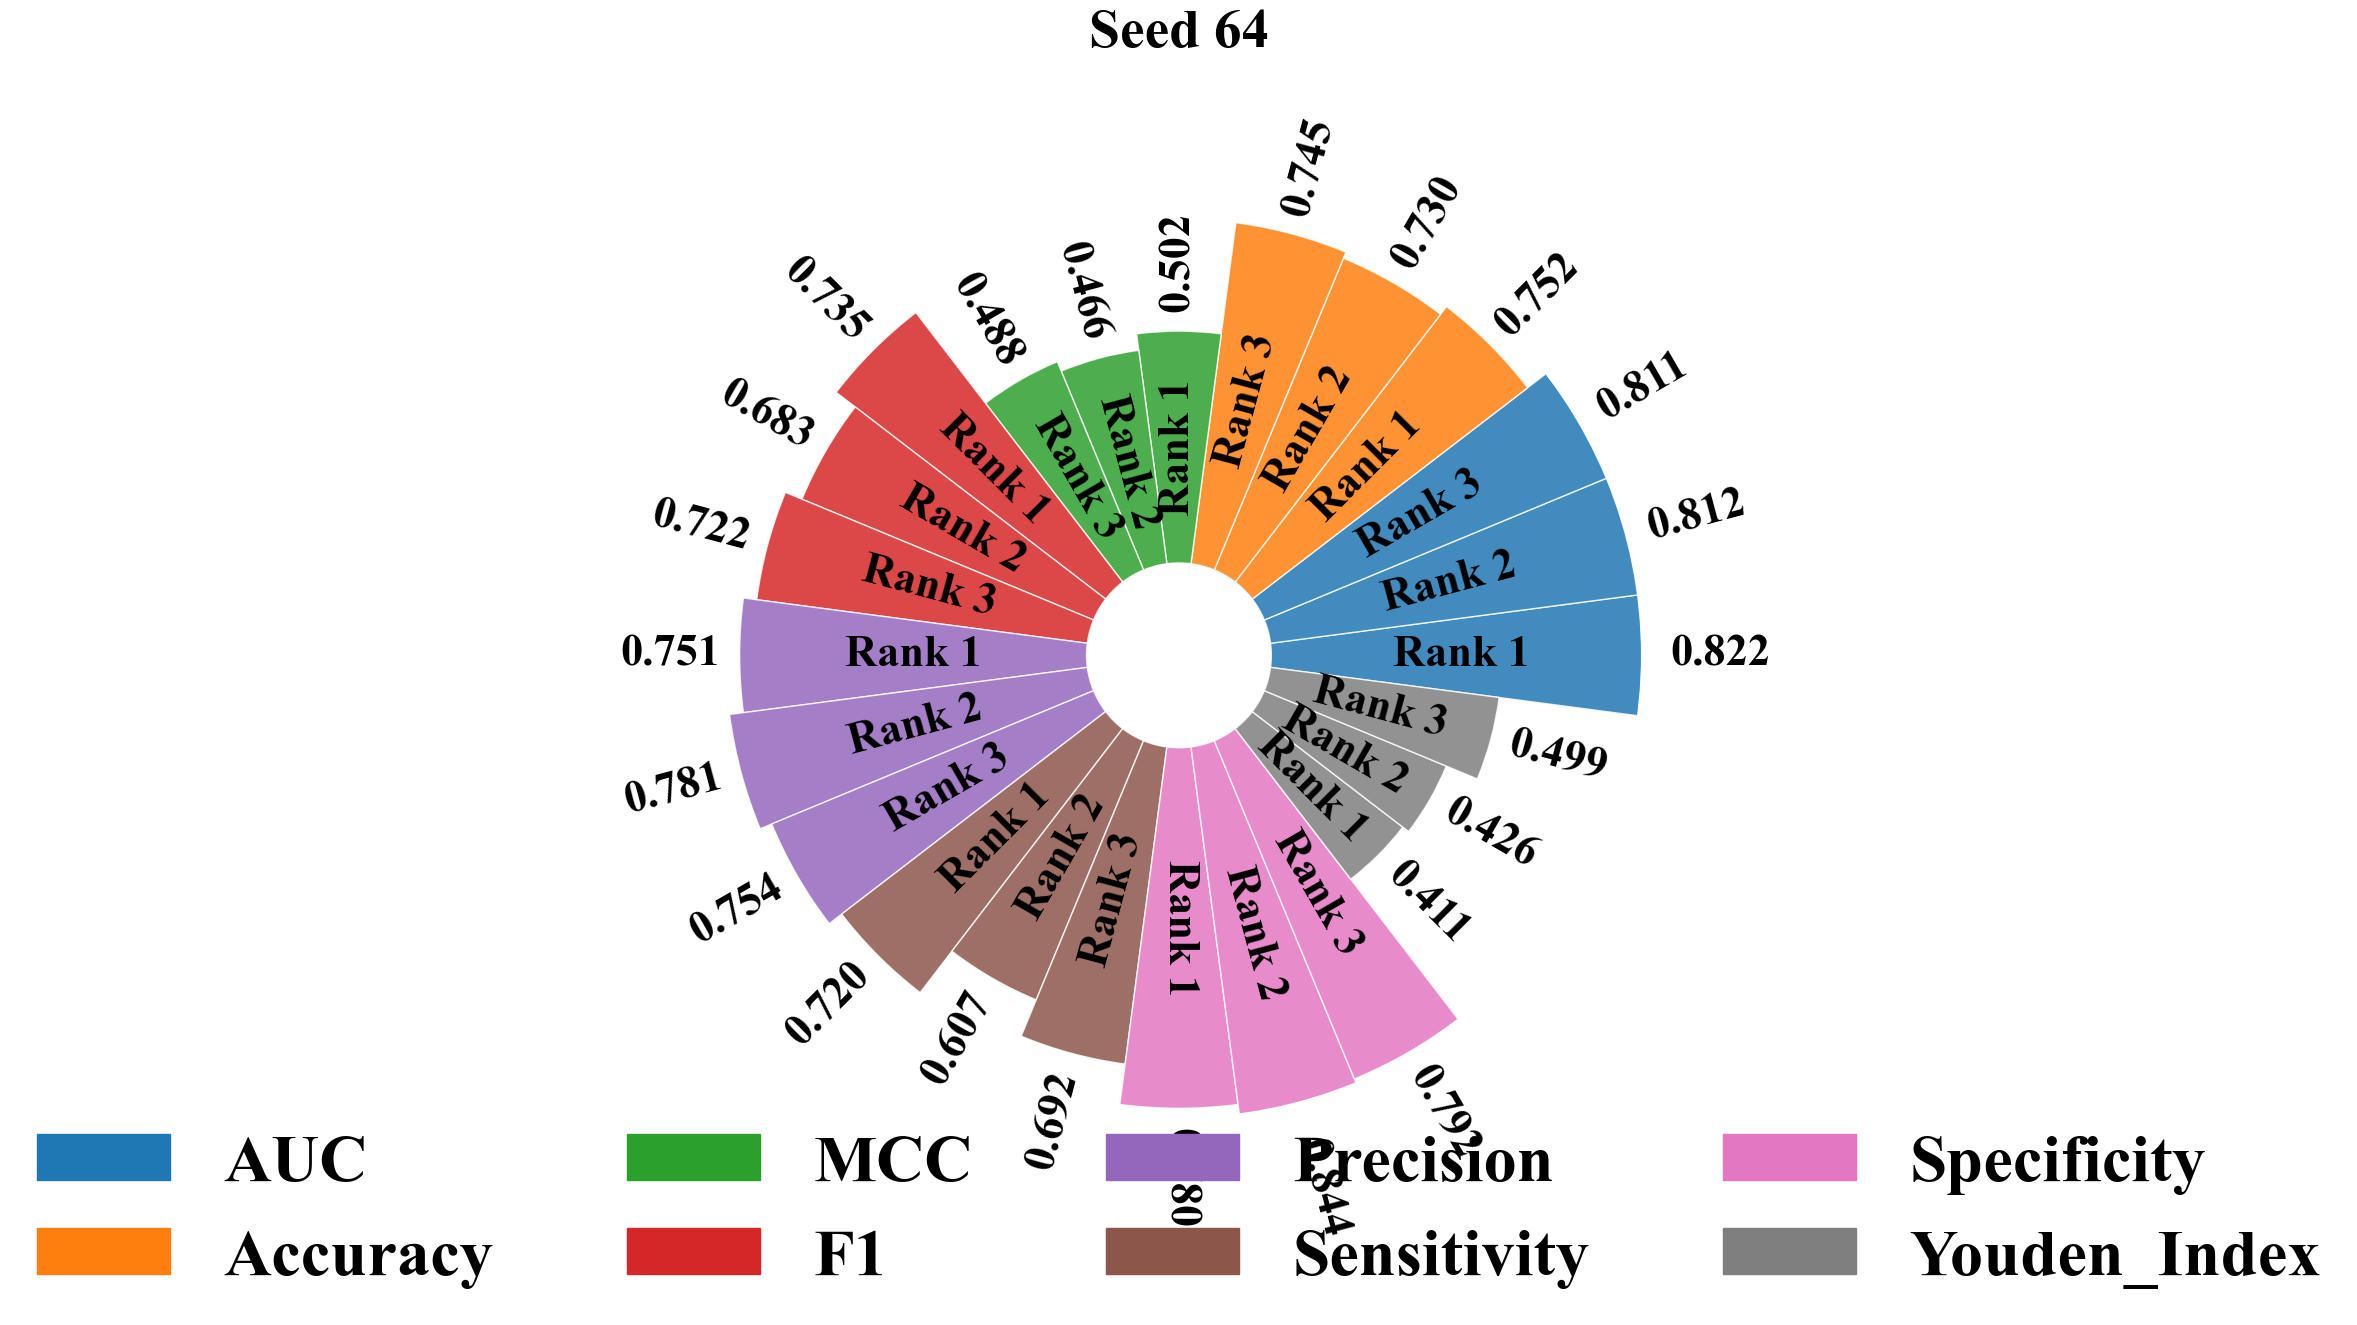

In [61]:
metrics = [
    'AUC', 'Accuracy', 'MCC', 'F1', 'Precision', 'Sensitivity', 'Specificity', 
    'Youden_Index'
]

models = ['Rank 1', 'Rank 2', 'Rank 3']

scores = scores

colors = {m: plt.cm.tab10(i % 10) for i, m in enumerate(metrics)}

num_metrics = len(metrics)
num_models = len(models)
width = 2 * np.pi / (num_metrics * num_models)

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))
plt.title("Seed 64", fontsize=40, fontweight='bold', y=1.15)

bottom = 0.2 

for i, metric in enumerate(metrics):
    values = scores[metric]
    color = colors[metric]

    for j, val in enumerate(values):
        theta = (i * num_models + j) * width
        
        bar = ax.bar(theta, 
                     val, 
                     width=width*1, 
                     color=color, 
                     alpha=0.85,
                     bottom=0.2, 
                     edgecolor='white', 
                     linewidth=1)

        rotation = np.degrees(theta)
        if 90 < rotation < 270:
            rotation += 180
            ha = 'right'
        else:
            ha = 'left'

        ax.text(theta, bottom + val/2, models[j],
                ha='center', va='center',
                rotation=rotation,
                rotation_mode='anchor',
                fontweight='bold',
                fontsize=32,
                color='black')

        ax.text(theta, 
                bottom + val + 0.15, 
                f"{val:.3f}",
                ha='center', va='center',
                rotation=rotation,
                rotation_mode='anchor',
                fontweight='bold',
                fontsize=32,
                color='black')

ax.set_ylim(0, 1.0)  
ax.set_yticklabels([])
ax.set_xticks([])


ax.grid(False)

ax.spines['polar'].set_visible(False)

legend_patches = [Patch(color=colors[m], label=m) for m in metrics]
plt.legend(handles=legend_patches,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.25),
           ncol=4,
           prop={'size':48, 'weight':'bold'},
           frameon=False)

plt.savefig("Metrics_Seed_64.pdf", format='pdf', bbox_inches='tight')

plt.show()